# Problem 
$.$ There are a large number of factors that can affect the value if a house property (eg. Location , Size ,, condition , time) these factors can change quite substantially from one property to another.

$.$ The housing market is very volatile industry and it;s quite dependent on demand and supply fluctuations not even to mention the economic factors such as interest rate and inflation.

# Objective of the studies
 The aim is to model the median house value which is the  $target Variable$.
 
 Overcome missing data witha basic $Unsupervised learning$ data imputation. 

In [1]:
# importing the necessary the libries
import os,sys,warnings
if not sys.warnoptions:    
    warnings.simplefilter('ignore')
    
import numpy as np
from numpy.linalg import pinv,inv
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns;sns.set(style='whitegrid')
%matplotlib inline

import geoplot as gplt
import geoplot.crs as gcrs
import mapclassify as mc

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, RegressorMixin,ClassifierMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

In [2]:
# importing the dataset
df = pd.read_csv(r"C:\Users\lamin\OneDrive\Desktop\Datafolder\cali housing data\housing.csv")

# Content
The data pertains to the houses found in a  given california district and some summary stats about them based on the 1990 census data.
The columns are as follows, their names are pretty self explanitory:

In [3]:
df.head() # the head of the dataset 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe() # statistical decription of the data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.isnull().sum() # checking for missing values

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# Data Imputation .
We will use the KNN Unsupervised Learning Imputation to impuse the missing 
data.

In [7]:
from sklearn.impute import KNNImputer

# use KNN to fill only total_bedrooms
imputer = KNNImputer(n_neighbors=5)

df[["total_bedrooms"]] = imputer.fit_transform(df[["total_bedrooms"]])

print("Missing values in total_bedrooms:", df["total_bedrooms"].isna().sum())

Missing values in total_bedrooms: 0


In [8]:
df.isnull().sum() # checking for missing values

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

We want to split the dataset into train and test set. We want to reserve data and use it to see how good the model is at prediction on unseen data.

In [9]:
x = df.drop("median_house_value", axis = 1)
y = df["median_house_value"]

In [10]:
x_train , x_test , y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Let do some Exploratory Data Analysis

We want to know a little more about our data, a  simple data exploration approach conducted here

## Univariate Histograms (One Variable at a Time)

Let’s look at the distribution of each feature using histograms.

When reading a histogram, check for:

- **Shape of the data**: Is it balanced or skewed?  
  (Some models work better with less skewed data.)
- **Outliers**: Are there extreme values far from most data?  
  (Too much noise can hurt model performance.)
- **Strange patterns**: Are there unusual gaps or spikes?  
  (These may indicate data quality issues.)
- **Scale of values**: Are feature values on very different ranges?  
  (Large scale differences can affect some models.)

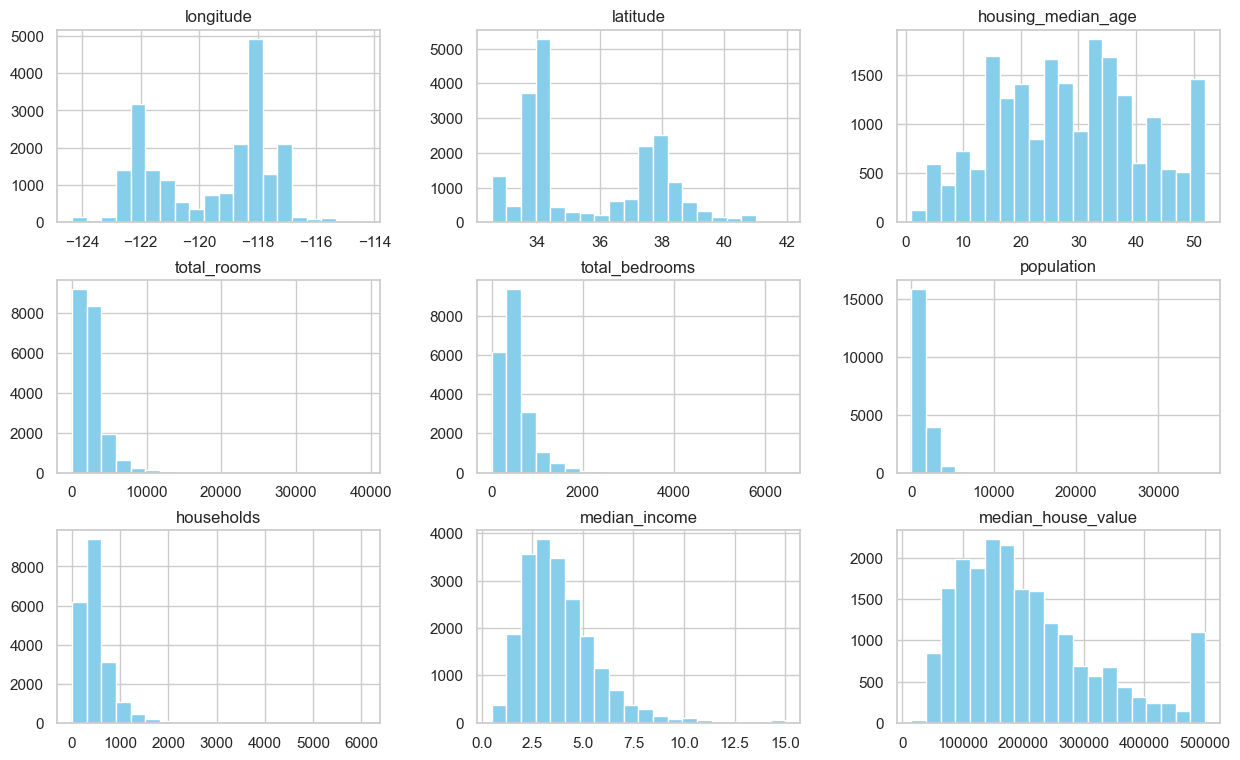

In [11]:
df.hist(bins= 20 , figsize= (15,9), color = "skyblue"); plt.show()

From the plots of the features we have few outliers present in the data.

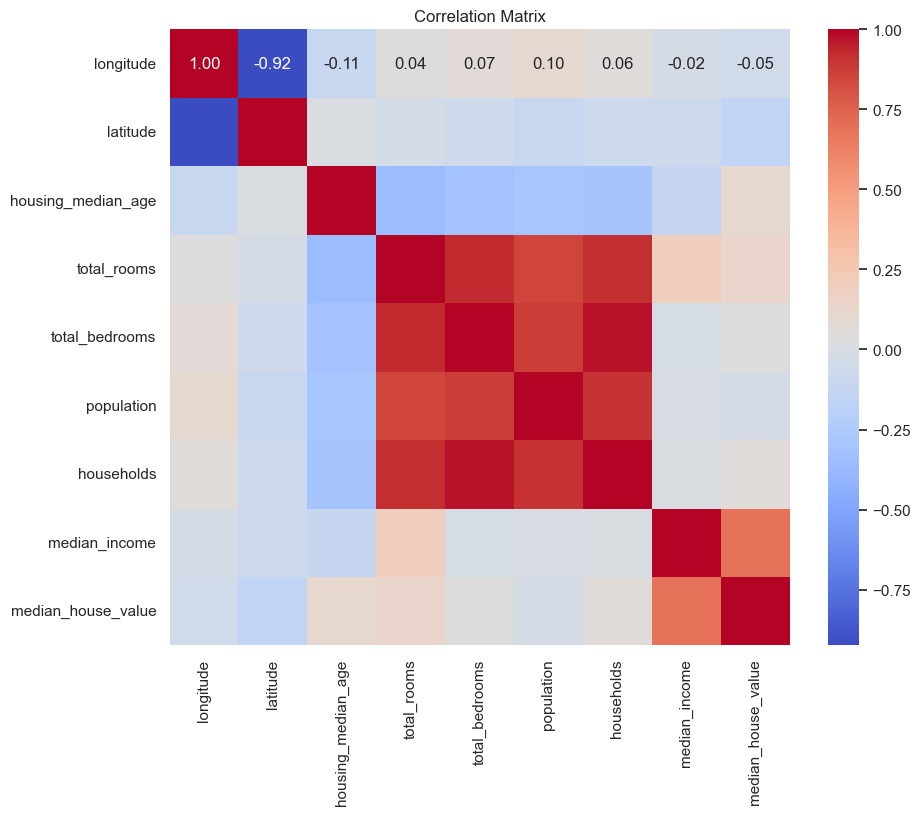

In [12]:
# let check on the correlation of the data
corr = df.corr(numeric_only = True) # for only numeric columns

plt.figure(figsize =(10,8))
sns.heatmap(corr , annot = True , cmap= 'coolwarm', fmt= ".2f")
plt.title("Correlation Matrix")
plt.show()

- **`median_income` is the most useful feature** for predicting `median_house_value` because it has the strongest correlation with the target.

- **Very low correlation** (like `-0.02` or `-0.05` for `population` or `longitude`) **does not always mean we should remove a feature**. It may still help the model, especially if the relationship is **non-linear**.

### Bivariate Scatter Plots (Comparing Two Features)

- A pairplot (scatter matrix) lets us compare features two at a time.
- It helps reveal relationships and trends that one-variable plots may miss.
- Color grouping can be added, but in large scatter matrices the colors may be difficult to tell apart.

### Things to check

- Unusual points and outliers across two features.
- Visible groups or clusters in 2D.
- Whether the points follow a clear linear trend or look mostly random.

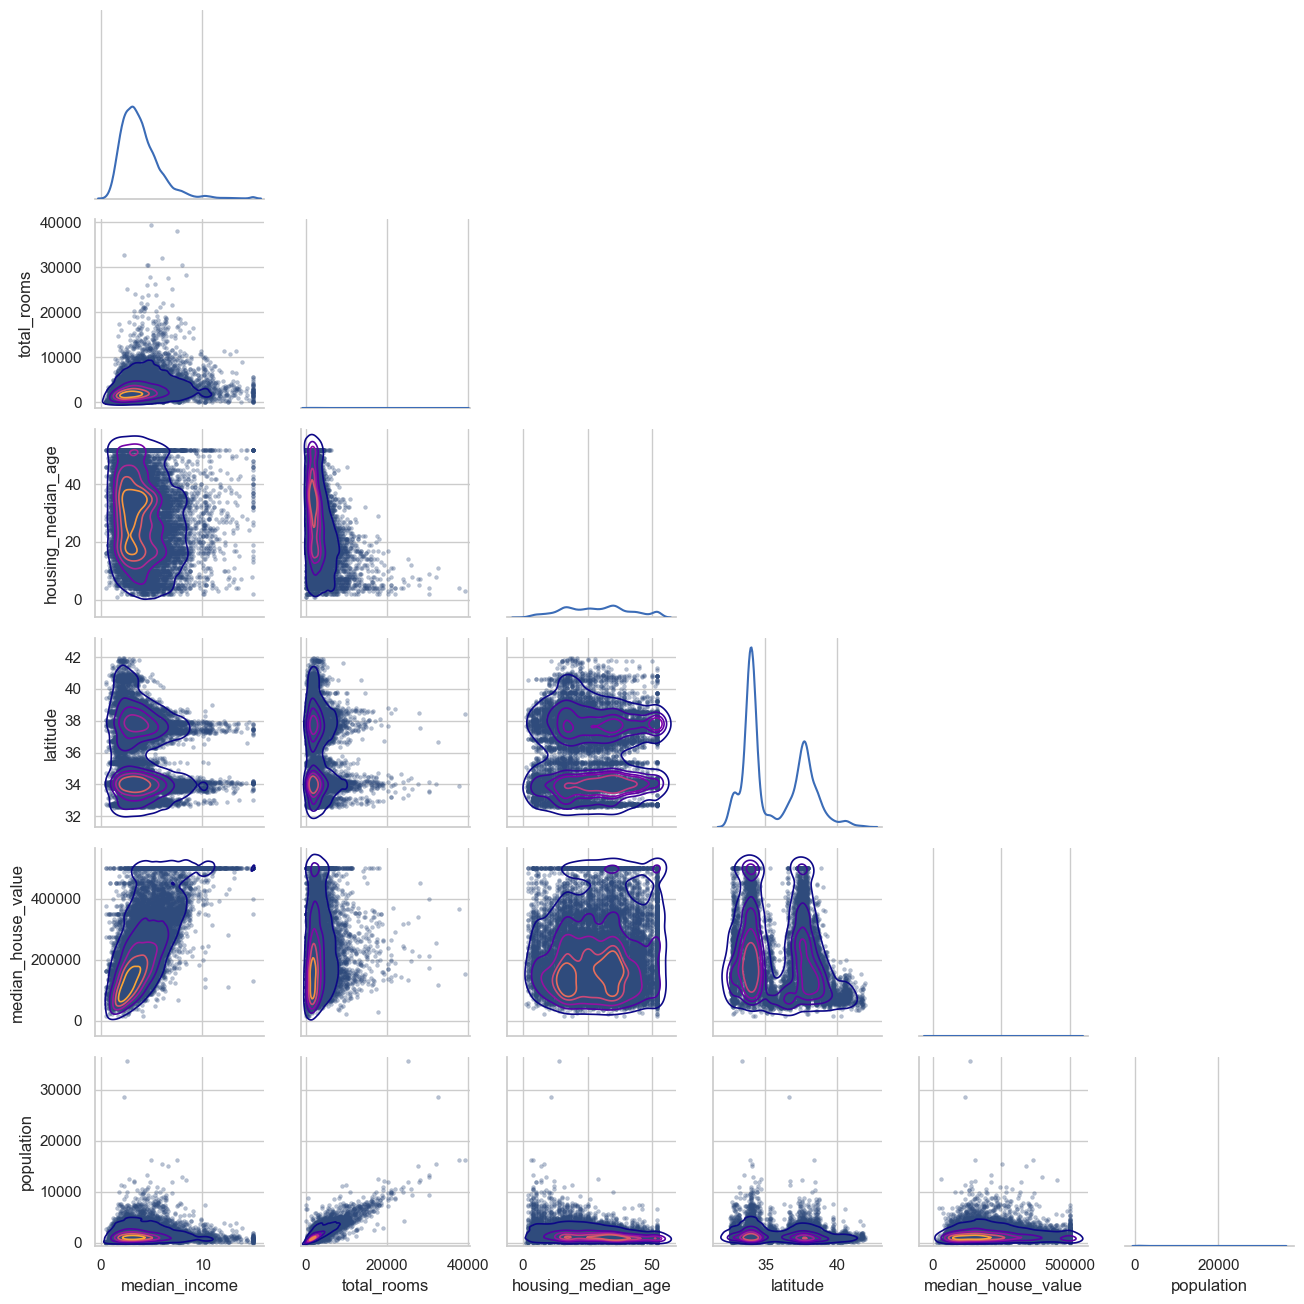

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# columns you want
tlist = [
    'median_income',
    'total_rooms',
    'housing_median_age',
    'latitude',
    'median_house_value',
    'population'
]

# style close to your image
sns.set_theme(style="whitegrid", context="notebook")

# build pair grid
g = sns.PairGrid(df[tlist], corner=True, height=2.2)

# lower triangle: scatter + kde contours
g.map_lower(
    sns.scatterplot,
    s=8, alpha=0.35, color="#2f4b7c", edgecolor=None
)
g.map_lower(
    sns.kdeplot,
    levels=6, cmap="plasma", linewidths=1.2
)

# diagonal: kde curve
g.map_diag(sns.kdeplot, color="#3b6cb7", lw=1.5, fill=False)

plt.tight_layout()
plt.show()

# In correlation to the  **Median  House  Value**


- **`median_income` vs `median_house_value`**: The relationship is mostly positive and close to linear, but there is noticeable spread around the trend. There is also a clear upper cap in `median_income`, which appears unusual in the plot.

- **`housing_median_age` vs `median_house_value`**: This relationship is strongly non-linear and widely scattered. KDE indicates two main age peaks (roughly 20 years apart), mostly concentrated in lower house values, plus another peak near high age and high value.

- **`total_rooms`/`population` vs `median_house_value`**: These relationships are more complex. Most data is concentrated at lower values, with some concentration at higher values and many points outside the main clusters (possible outliers).


## Geospatial Multivariate Data

- **Multivariate visualization** can reveal more insight than bivariate plots because it shows relationships among multiple features at once.
- Adding **color** to scatter plots introduces an extra dimension, making patterns easier to interpret when overlap is limited.
- For this dataset, **geographic visualization** is especially useful to understand how location affects other variables.
- Since the data includes latitude/longitude, tools like **GeoPandas**, **Folium**, and **Plotly** are helpful for geospatial analysis.

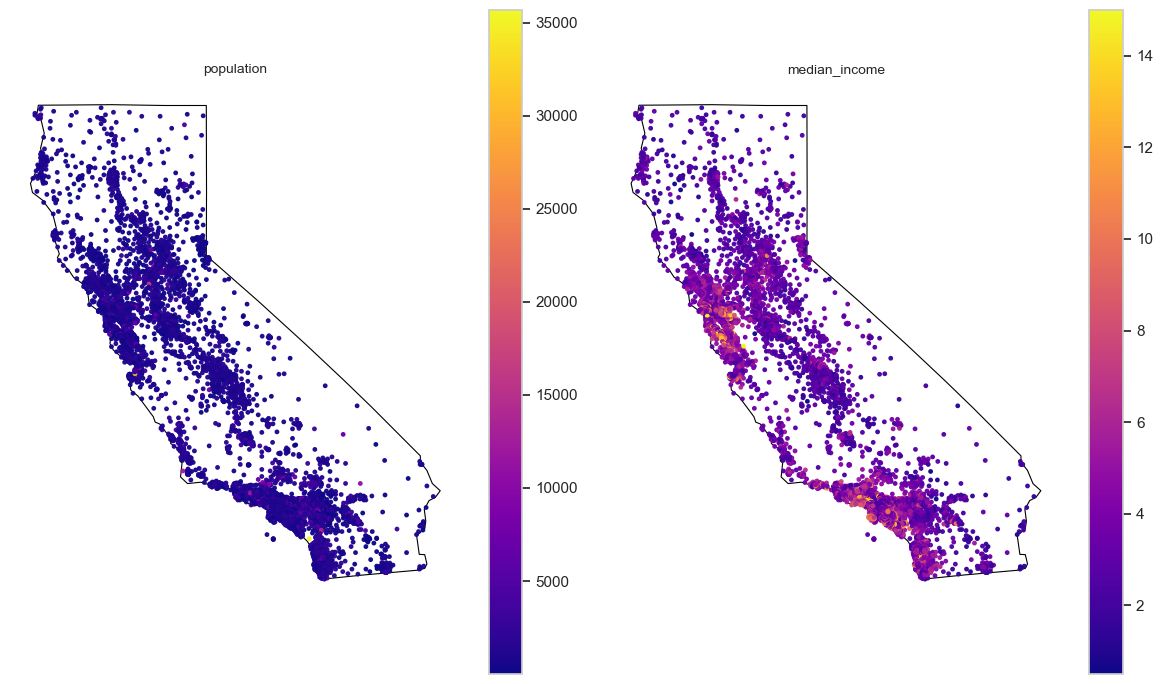

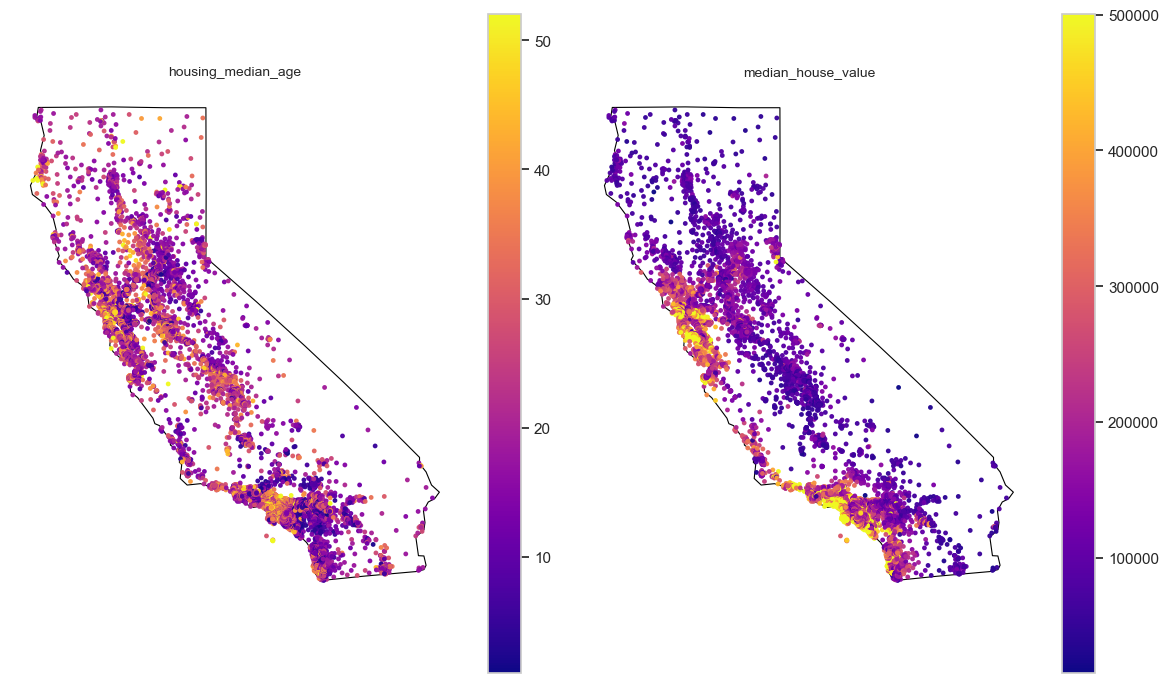

In [14]:
import matplotlib.pyplot as plt
import geopandas as gpd

# ---------- helper ----------
def plotTwo(gdf, cols, cmap="plasma", marker_size=6):
    fig, axes = plt.subplots(1, 2, figsize=(12, 7))
    
    for ax, col in zip(axes, cols):
        # California outline (if available)
        try:
            ca_boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)
        except:
            pass
        
        gdf.plot(
            ax=ax,
            column=col,
            cmap=cmap,
            markersize=marker_size,
            legend=True,
            alpha=0.95
        )
        ax.set_title(col, fontsize=10)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

# ---------- make sure df is GeoDataFrame ----------
# needs columns: longitude, latitude
if not isinstance(df, gpd.GeoDataFrame):
    df = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326"
    )

# ---------- California boundary ----------
usa = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
ca_boundary = usa[usa["name"] == "California"]

# ---------- your calls ----------
plotTwo(df, ['population', 'median_income'])
plotTwo(df, ['housing_median_age', 'median_house_value'])

# remove geometry after plotting (if you want plain DataFrame again)
if 'geometry' in df.columns:
    del df['geometry']

We will use $Bayesian$ $Linear$ $Regression$ $Model$ to solve this problem

In [15]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------------
# 4) Preprocessing
#    - numeric: median impute + scaling
#    - categorical: most_frequent impute + one-hot
# -------------------------------------------------
num_cols = x_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = x_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

In [16]:
# -------------------------------------------------
#  Baseline Bayesian Ridge model pipeline
# -------------------------------------------------
model = Pipeline(steps=[
    ("prep", preprocess),
    ("reg", BayesianRidge())
])


In [17]:
# 5-Fold Cross Validation on TRAIN set only
# -------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    x_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_mae = -cv_results["test_MAE"]
cv_rmse = -cv_results["test_RMSE"]
cv_r2 = cv_results["test_R2"]

print("5-Fold CV (TRAIN set):")
print(f"MAE : {cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"R2  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

5-Fold CV (TRAIN set):
MAE : 49664.631 ± 993.625
RMSE: 68596.932 ± 1316.025
R2  : 0.648 ± 0.013


### 5-Fold Cross-Validation Results (Training Set)

- **R² = 0.648 ± 0.013**  
  The model explains about **64.8%** of the variation in `median_house_value`.  
  This is a good baseline for a Bayesian linear model.

- **MAE = 49,664.631 ± 993.625**  
  On average, predictions are off by about **$49.7k**.

- **RMSE = 68,596.932 ± 1,316.025**  
  RMSE is higher than MAE, which suggests some **larger errors/outliers** are present.

- **Low standard deviation across folds**  
  The small `±` values mean the model performs **consistently** across different train/validation splits.

### Summary
These are **training-set cross-validation** results (not final test results).  
They show a **stable and reasonable baseline**, with room for improvement using feature engineering and non-linear models.

In [18]:
#  Fit on full TRAIN set, evaluate on TEST set
# -------------------------------------------------
model.fit(x_train, y_train)
y_pred = model.predict(x_test)   # use X_test (capital X)

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)  # no squared arg
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("\nHeld-out TEST set performance:")
print(f"MAE : {test_mae:.3f}")
print(f"RMSE: {test_rmse:.3f}")
print(f"R2  : {test_r2:.3f}")


Held-out TEST set performance:
MAE : 50712.697
RMSE: 70044.433
R2  : 0.626


### Held-out Test Set Performance (Unseen Data)

- **MAE = 50,712.697**  
  On average, predictions are off by about **$50.7k** on unseen test data.

- **RMSE = 70,044.433**  
  The typical error size is around **$70k**, and this being higher than MAE suggests some larger prediction misses.

- **R² = 0.626**  
  The model explains about **62.6%** of the variance in `median_house_value` on unseen data.

### Interpretation

- Test performance is slightly lower than CV/training performance (R² dropped from ~0.648 to ~0.626), which is normal.
- The gap is small, so the model appears to **generalize reasonably well** and is **not severely overfitting**.
- This is a solid **baseline Bayesian regression** result, but there is room to improve with better features and non-linear models.

$Random$ $Forest$ is a strong next model after Bayesian Ridge because housing data often contains non-linear relationships and feature interactions that a linear model may not capture well.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

#  preprocessing for Random Forest
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_rf = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

#  model pipeline
rf_model = Pipeline(steps=[
    ("prep", preprocess_rf),
    ("reg", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

#  5-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_mean_squared_error", "R2": "r2"}

cv_results_rf = cross_validate(
    rf_model, x_train, y_train,
    cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1
)

cv_mae_rf = -cv_results_rf["test_MAE"]
cv_rmse_rf = np.sqrt(-cv_results_rf["test_RMSE"])
cv_r2_rf = cv_results_rf["test_R2"]

print("Random Forest - 5-Fold CV (TRAIN set):")
print(f"MAE : {cv_mae_rf.mean():.3f} ± {cv_mae_rf.std():.3f}")
print(f"RMSE: {cv_rmse_rf.mean():.3f} ± {cv_rmse_rf.std():.3f}")
print(f"R2  : {cv_r2_rf.mean():.3f} ± {cv_r2_rf.std():.3f}")


Random Forest - 5-Fold CV (TRAIN set):
MAE : 32129.113 ± 501.017
RMSE: 49200.442 ± 1105.390
R2  : 0.819 ± 0.005


### Random Forest — 5-Fold CV Results (Training Set)

- **MAE = 32,129.113 ± 501.017**  
  On average, predictions are off by about **$32.1k**, which is a clear improvement over the Bayesian baseline.

- **RMSE = 49,200.442 ± 1,105.390**  
  Typical prediction error is about **$49.2k**.  
  Since RMSE is still higher than MAE, some larger errors remain, but they are much smaller than before.

- **R² = 0.819 ± 0.005**  
  The model explains about **81.9%** of the variance in house values, which is a strong fit for this dataset.

- **Very small fold-to-fold variation**  
  The low `±` values indicate the model is **stable and consistent** across cross-validation splits.

### Overall Interpretation

Random Forest performs **substantially better** than the Bayesian Ridge baseline on cross-validation:
- lower MAE,
- lower RMSE,
- higher R².

This suggests the dataset has important **non-linear patterns** and interactions that Random Forest captures more effectively than a linear Bayesian model.

In [20]:
#  test set performance
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print("\nRandom Forest - Held-out TEST set:")
print(f"MAE : {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"R2  : {r2_score(y_test, y_pred_rf):.3f}")


Random Forest - Held-out TEST set:
MAE : 31492.766
RMSE: 48753.894
R2  : 0.819


### Random Forest — Held-out Test Set Performance

- **MAE = 31,492.766**  
  On unseen test data, predictions are off by about **$31.5k** on average.

- **RMSE = 48,753.894**  
  Typical error magnitude is about **$48.8k**.  
  RMSE is higher than MAE, meaning some larger prediction errors still exist, but overall error is much lower than the Bayesian baseline.

- **R² = 0.819**  
  The model explains about **81.9%** of the variance in `median_house_value` on unseen data, which is strong generalization performance.

### Interpretation

- Test metrics are almost identical to CV metrics, indicating **good generalization** and **little overfitting**.
- Compared with your Bayesian Ridge test result (`R² ≈ 0.626`), Random Forest is a **major improvement**.
- This confirms the housing problem benefits from a model that captures **non-linear relationships** and feature interactions.